In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/dl_project

/content/drive/MyDrive/dl_project


In [ ]:
!ls

FSDD_dataset  FSDD_dataset.zip	recordings


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/dl_project/FSDD_dataset"
files = os.listdir(dataset_path)
print("Total files:", len(files))
print(files)

Total files: 3000
['6_theo_27.wav', '7_george_37.wav', '0_jackson_34.wav', '6_george_48.wav', '5_george_47.wav', '2_george_11.wav', '1_george_33.wav', '4_george_3.wav', '0_nicolas_42.wav', '3_lucas_2.wav', '3_theo_9.wav', '9_theo_11.wav', '0_yweweler_39.wav', '0_theo_48.wav', '6_theo_4.wav', '3_george_22.wav', '3_lucas_14.wav', '5_nicolas_4.wav', '1_nicolas_43.wav', '3_george_30.wav', '9_yweweler_46.wav', '1_nicolas_33.wav', '5_yweweler_39.wav', '4_nicolas_42.wav', '8_lucas_49.wav', '0_yweweler_43.wav', '3_nicolas_31.wav', '6_yweweler_8.wav', '6_george_4.wav', '8_nicolas_13.wav', '7_yweweler_34.wav', '8_yweweler_5.wav', '7_lucas_4.wav', '0_yweweler_47.wav', '4_lucas_21.wav', '9_yweweler_15.wav', '1_theo_42.wav', '6_george_38.wav', '1_jackson_30.wav', '5_jackson_34.wav', '2_nicolas_14.wav', '1_yweweler_44.wav', '7_lucas_37.wav', '7_theo_26.wav', '0_nicolas_18.wav', '0_george_7.wav', '5_theo_34.wav', '6_theo_3.wav', '8_jackson_47.wav', '6_lucas_20.wav', '2_jackson_42.wav', '4_nicolas_35.

In [ ]:
!pip install librosa

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = []
y = []

for file in files:
    file_path = os.path.join(dataset_path, file)

    signal, sr = librosa.load(file_path, sr=None)  # keep 8kHz

    mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sr,
    n_mfcc=40,
    n_fft=512,
    hop_length=256)

    X.append(mfcc)

    digit = int(file.split("_")[0])
    y.append(digit)

print("Total samples:", len(X))
print("Shape of one MFCC:", X[2656].shape)



Total samples: 3000
Shape of one MFCC: (40, 16)


In [ ]:
print("Shape of one MFCC:", X[26].shape)

Shape of one MFCC: (40, 10)


In [ ]:
max_len = max(mfcc.shape[1] for mfcc in X)
print("Max time frames:", max_len)

Max time frames: 72


In [ ]:
X_padded = []

for mfcc in X:
    pad_width = max_len - mfcc.shape[1]
    mfcc_padded = np.pad(mfcc,
                         pad_width=((0,0),(0,pad_width)),
                         mode='constant')
    X_padded.append(mfcc_padded)

X = np.array(X_padded)
y = np.array(y)

print("Final shape:", X.shape)


Final shape: (3000, 40, 72)


In [ ]:
num_samples, n_mfcc, time_steps = X.shape

X_reshaped = X.reshape(num_samples, -1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(num_samples, n_mfcc, time_steps)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.17, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2489, 40, 72)
Test shape: (511, 40, 72)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)

torch.Size([2489, 1, 40, 72])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.3)

        # We must calculate flatten size dynamically
        self._to_linear = None
        self._get_conv_output()

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 10)   # 10 digits (0-9)

    def _get_conv_output(self):
        x = torch.randn(1, 1, 40, X_train.shape[3])
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        self._to_linear = x.numel()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=5760, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
import matplotlib.pyplot as plt

epochs = 15

train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    # -------- Test Accuracy ----------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")

Epoch [1/15] Loss: 2.0741 Train Acc: 28.04% Test Acc: 64.77%
Epoch [2/15] Loss: 1.0460 Train Acc: 68.06% Test Acc: 88.65%
Epoch [3/15] Loss: 0.6018 Train Acc: 83.53% Test Acc: 92.95%
Epoch [4/15] Loss: 0.3932 Train Acc: 89.96% Test Acc: 96.09%
Epoch [5/15] Loss: 0.2896 Train Acc: 92.29% Test Acc: 95.50%
Epoch [6/15] Loss: 0.2319 Train Acc: 94.25% Test Acc: 95.50%
Epoch [7/15] Loss: 0.2070 Train Acc: 94.86% Test Acc: 95.50%
Epoch [8/15] Loss: 0.1580 Train Acc: 95.50% Test Acc: 97.06%
Epoch [9/15] Loss: 0.1183 Train Acc: 96.91% Test Acc: 96.87%
Epoch [10/15] Loss: 0.1341 Train Acc: 96.75% Test Acc: 94.72%
Epoch [11/15] Loss: 0.1391 Train Acc: 96.95% Test Acc: 95.50%
Epoch [12/15] Loss: 0.1137 Train Acc: 97.15% Test Acc: 97.26%
Epoch [13/15] Loss: 0.1471 Train Acc: 96.71% Test Acc: 96.28%
Epoch [14/15] Loss: 0.1222 Train Acc: 96.30% Test Acc: 96.48%
Epoch [15/15] Loss: 0.0881 Train Acc: 97.75% Test Acc: 96.87%


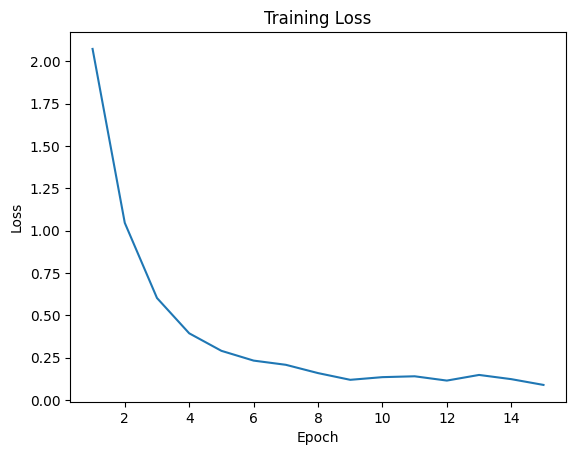

In [ ]:
plt.figure()
plt.plot(range(1, epochs+1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

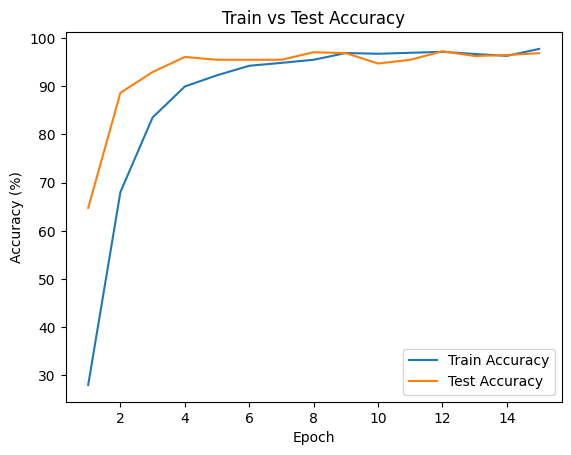

In [ ]:
plt.figure()
plt.plot(range(1, epochs+1), train_accuracies)
plt.plot(range(1, epochs+1), test_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy")
plt.legend(["Train Accuracy", "Test Accuracy"])
plt.show()

In [ ]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=40, hidden_size=128, num_layers=2, num_classes=10):
        super(LSTMModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, time, 40)
        out, _ = self.lstm(x)

        # Take last time step
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)

        return out

In [ ]:
# Suppose X is (N, 40, T)

X_lstm = X.transpose(0, 2, 1)   # → (N, T, 40)

import torch

X_tensor = torch.tensor(X_lstm, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

In [ ]:
X_lstm.shape, y.shape,X.shape

((3000, 72, 40), (3000,), (3000, 40, 72))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.17, random_state=42
)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import matplotlib.pyplot as plt

epochs = 15

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # 🔍 Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/15 | Train Loss: 2.3054 | Train Acc: 0.1025 | Val Loss: 2.3088 | Val Acc: 0.0920
Epoch 2/15 | Train Loss: 2.3049 | Train Acc: 0.1037 | Val Loss: 2.3036 | Val Acc: 0.0881
Epoch 3/15 | Train Loss: 2.3036 | Train Acc: 0.0984 | Val Loss: 2.3048 | Val Acc: 0.0705
Epoch 4/15 | Train Loss: 2.3035 | Train Acc: 0.1004 | Val Loss: 2.3061 | Val Acc: 0.0705
Epoch 5/15 | Train Loss: 2.3028 | Train Acc: 0.1041 | Val Loss: 2.3061 | Val Acc: 0.0705
Epoch 6/15 | Train Loss: 2.3032 | Train Acc: 0.0956 | Val Loss: 2.3066 | Val Acc: 0.0705
Epoch 7/15 | Train Loss: 2.3032 | Train Acc: 0.1037 | Val Loss: 2.3062 | Val Acc: 0.0705
Epoch 8/15 | Train Loss: 2.3030 | Train Acc: 0.0876 | Val Loss: 2.3050 | Val Acc: 0.0881
Epoch 9/15 | Train Loss: 2.3030 | Train Acc: 0.1041 | Val Loss: 2.3053 | Val Acc: 0.0920
Epoch 10/15 | Train Loss: 2.3029 | Train Acc: 0.0916 | Val Loss: 2.3063 | Val Acc: 0.0705
Epoch 11/15 | Train Loss: 2.3026 | Train Acc: 0.1049 | Val Loss: 2.3064 | Val Acc: 0.0705
Epoch 12/15 | Train

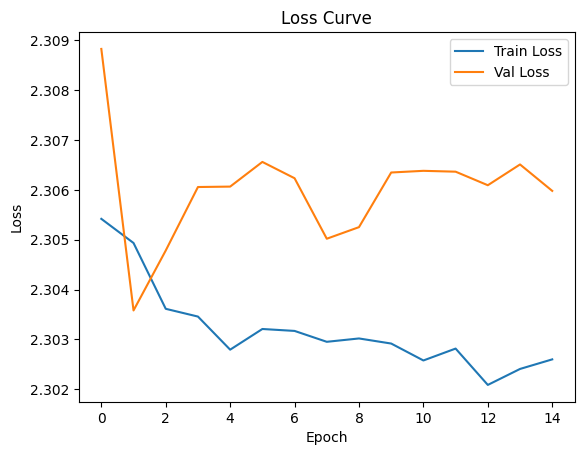

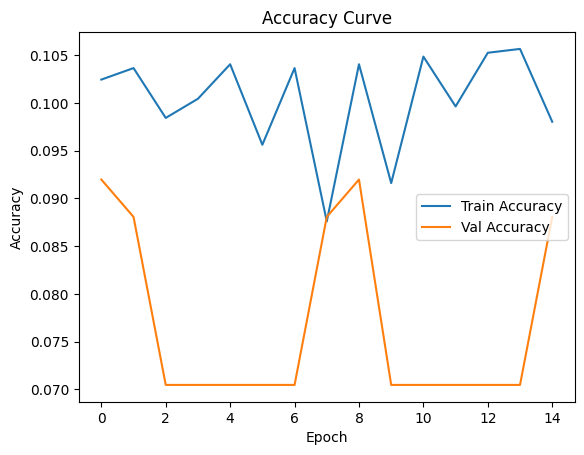

In [ ]:
# Loss Plot
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

“For very short-duration speech signals, temporal dependencies are limited, making LSTM less effective compared to CNN, which captures spectral patterns efficiently.”

solution:

“The CNN extracts spatial-spectral features from MFCC representations, while the LSTM captures temporal dependencies across these learned features, resulting in improved or more stable performance.”

In [ ]:
import os
import random
import librosa
import numpy as np
import soundfile as sf

input_path = "/content/drive/MyDrive/dl_project/FSDD_dataset"

output_path = "/content/drive/MyDrive/dl_project/FSDD_multi_dataset"

os.makedirs(output_path, exist_ok=True)

# Step 1: Group files by speaker and digit
data = {}

for file in os.listdir(input_path):
    if file.endswith(".wav"):
        digit, speaker, idx = file.replace(".wav", "").split("_")

        if speaker not in data:
            data[speaker] = {str(i): [] for i in range(10)}

        data[speaker][digit].append(file)

# Step 2: Generate numbers 0–99
numbers = [f"{i:02d}" for i in range(100)]

# Step 3: Create dataset
sr = 8000  # keep same

for speaker in data:
    print(f"Processing speaker: {speaker}")

    for num in numbers:
        d1, d2 = num[0], num[1]

        for k in range(5):  # 5 variations
            file1 = random.choice(data[speaker][d1])
            file2 = random.choice(data[speaker][d2])

            # Load audio
            y1, _ = librosa.load(os.path.join(input_path, file1), sr=sr)
            y2, _ = librosa.load(os.path.join(input_path, file2), sr=sr)

            # Optional: small silence between digits
            silence = np.zeros(int(0.05 * sr))  # 50ms

            # Concatenate
            y = np.concatenate([y1, silence, y2])

            # Output filename
            out_name = f"{num}_{speaker}_{k}.wav"
            out_file = os.path.join(output_path, out_name)

            # Save
            sf.write(out_file, y, sr)

print("✅ Dataset creation complete!")

Processing speaker: nicolas
Processing speaker: yweweler
Processing speaker: jackson
Processing speaker: theo
Processing speaker: george
Processing speaker: lucas
✅ Dataset creation complete!


In [ ]:
import os
import random
import librosa
import numpy as np
import soundfile as sf

input_path = "/content/drive/MyDrive/dl_project/FSDD_dataset"

output_path = "/content/drive/MyDrive/dl_project/FSDD_multi_dataset"

os.makedirs(output_path, exist_ok=True)

# Step 1: Group files
data = {}

for file in os.listdir(input_path):
    if file.endswith(".wav"):
        parts = file.replace(".wav", "").split("_")

        if len(parts) != 3:
            print("Skipping bad file:", file)
            continue

        digit, speaker, idx = parts

        if speaker not in data:
            data[speaker] = {str(i): [] for i in range(10)}

        data[speaker][digit].append(file)

# 🔍 DEBUG: Check counts
for speaker in data:
    print(f"\nSpeaker: {speaker}")
    for d in range(10):
        print(f"Digit {d}: {len(data[speaker][str(d)])}")

# Step 2
numbers = [f"{i:02d}" for i in range(100)]
sr = 8000

total_saved = 0

# Step 3
for speaker in data:
    print(f"\nProcessing {speaker}...")

    # Check if all digits exist
    valid = True
    for d in range(10):
        if len(data[speaker][str(d)]) == 0:
            print(f"❌ Missing digit {d} for {speaker}")
            valid = False

    if not valid:
        continue

    for num in numbers:
        d1, d2 = num[0], num[1]

        for k in range(5):
            try:
                file1 = random.choice(data[speaker][d1])
                file2 = random.choice(data[speaker][d2])

                y1, _ = librosa.load(os.path.join(input_path, file1), sr=sr)
                y2, _ = librosa.load(os.path.join(input_path, file2), sr=sr)

                silence = np.zeros(int(0.05 * sr))

                y = np.concatenate([y1, silence, y2])

                # UNIQUE filename (avoid overwrite)
                out_name = f"{num}_{speaker}_{k}_{total_saved}.wav"
                out_file = os.path.join(output_path, out_name)

                sf.write(out_file, y, sr)

                total_saved += 1

            except Exception as e:
                print("Error:", e)

print("\n✅ Done!")
print("Total files created:", total_saved)


Speaker: nicolas
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Speaker: yweweler
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Speaker: jackson
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Speaker: theo
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Speaker: george
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Speaker: lucas
Digit 0: 50
Digit 1: 50
Digit 2: 50
Digit 3: 50
Digit 4: 50
Digit 5: 50
Digit 6: 50
Digit 7: 50
Digit 8: 50
Digit 9: 50

Processing nicolas...

Processing yweweler...

Processing jackson...

Processing theo...

Processing george...

Processing lucas...

✅ Done!
Total files created: 3000
